# Model Result Comparison and Best Model Selection

1. Compare Baseline CNN, ResNet18, DenseNet121, EfficientNet, and their variants.
2. Use overall metrics: accuracy, macro F1, weighted F1, MAE, and QWK.
3. Compare per-class F1 scores for Normal, Doubtful, Mild, Moderate, and Severe.
4. Analyse error distance and confusion matrices.
5. Select the best model

In [5]:
# 1. Imports and path setup
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
# outputs/results
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        results_path = candidate / "outputs" / "results"

        if results_path.exists() and results_path.is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not find the project root containing outputs/results.\n"
        "Please make sure:\n"
        "1. This notebook is inside the 760-Group1 project folder, and\n"
        "2. The CSV files are stored in outputs/results."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "outputs" / "results"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "model_comparison"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables" / "model_comparison"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)
print("Tables directory:", TABLES_DIR)
print("Results folder exists:", RESULTS_DIR.exists())

Current working directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\notebooks
Project root: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1
Results directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\results
Figures directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison
Tables directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\tables\model_comparison
Results folder exists: True


In [7]:
# 2. Check available CSV files
csv_files = sorted([p.name for p in RESULTS_DIR.glob("*.csv")])
print(f"Number of CSV files found: {len(csv_files)}")

for name in csv_files:
    print(name)

Number of CSV files found: 78
baseline_confusion_matrix.csv
baseline_per_class_metrics.csv
baseline_test_metrics.csv
baseline_test_predictions.csv
baseline_training_history.csv
baseline_training_summary.csv
baseline_vs_resnet18_comparison.csv
baseline_vs_resnet18_per_class_f1.csv
dataset_summary.csv
densenet121_classweighted_confusion_matrix.csv
densenet121_classweighted_gradcam_predictions.csv
densenet121_classweighted_per_class_metrics.csv
densenet121_classweighted_test_metrics.csv
densenet121_classweighted_test_predictions.csv
densenet121_classweighted_training_history.csv
densenet121_classweighted_training_summary.csv
densenet121_confusion_matrix.csv
densenet121_gradcam_predictions.csv
densenet121_ordinal_confusion_matrix.csv
densenet121_ordinal_gradcam_predictions.csv
densenet121_ordinal_per_class_metrics.csv
densenet121_ordinal_test_metrics.csv
densenet121_ordinal_test_predictions.csv
densenet121_ordinal_training_history.csv
densenet121_ordinal_training_summary.csv
densenet121_pe

- `baseline_*` → Baseline CNN
- `resnet18_*` → ResNet18
- `densenet121_*` → DenseNet121
- `efficientnet_*` → EfficientNet
- `*_classweighted_*` → class-weighted version
- `*_ordinal_*` → ordinal-aware version
- otherwise → standard version

In [8]:
# 3. Helper functions
CLASS_ORDER = ["Normal", "Doubtful", "Mild", "Moderate", "Severe"]

MODEL_ORDER = [
    "Baseline CNN",
    "ResNet18",
    "ResNet18 (class-weighted)",
    "ResNet18 (ordinal)",
    "DenseNet121",
    "DenseNet121 (class-weighted)",
    "DenseNet121 (ordinal)",
    "EfficientNet",
    "EfficientNet (class-weighted)",
    "EfficientNet (ordinal)",
]


def parse_model_variant(filename: str):
    name = filename.lower()
    if name.startswith("baseline"):
        base_model = "Baseline CNN"
        raw_model = "baseline"
    elif name.startswith("resnet18"):
        base_model = "ResNet18"
        raw_model = "resnet18"
    elif name.startswith("densenet121"):
        base_model = "DenseNet121"
        raw_model = "densenet121"
    elif name.startswith("efficientnet"):
        base_model = "EfficientNet"
        raw_model = "efficientnet"
    else:
        base_model = "Unknown"
        raw_model = "unknown"

    if "classweighted" in name:
        variant = "class-weighted"
    elif "ordinal" in name:
        variant = "ordinal"
    else:
        variant = "standard"

    if variant == "standard":
        display_name = base_model
    else:
        display_name = f"{base_model} ({variant})"

    return raw_model, base_model, variant, display_name


def to_percentage_if_needed(x):
    # Convert values from 0-1 to 0-100. Keep values already above 1 unchanged.
    if pd.isna(x):
        return x
    return x * 100 if abs(x) <= 1 else x


def sort_by_model_order(df, label_col="model_variant"):
    order_map = {name: i for i, name in enumerate(MODEL_ORDER)}
    return df.assign(_order=df[label_col].map(order_map).fillna(999)).sort_values("_order").drop(columns="_order")


def save_current_figure(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

# 1 — Overall metrics comparison
- **Macro F1**: we need performance across all OA grades.
- **QWK**: grading is ordinal; predicting Grade 0 as Grade 1 is less serious than predicting Grade 0 as Grade 4.
- **MAE**: measures the average grade distance between the true label and predicted label.
- **Accuracy**: useful but should not be the only criterion.

In [9]:
# 4. Load all *_test_metrics.csv 

metric_files = sorted(RESULTS_DIR.glob("*_test_metrics.csv"))
metric_rows = []

for file in metric_files:
    raw_model, base_model, variant, display_name = parse_model_variant(file.name)
    df = pd.read_csv(file).copy()

    df["source_file"] = file.name
    df["raw_model"] = raw_model
    df["base_model"] = base_model
    df["variant"] = variant
    df["model_variant"] = display_name

    metric_rows.append(df)

if metric_rows:
    overall_df = pd.concat(metric_rows, ignore_index=True)
else:
    raise FileNotFoundError(
        f"No *_test_metrics.csv files found in {RESULTS_DIR}. "
        "Please check that your result CSV files are in outputs/results."
    )

# Convert numeric columns safely
for col in overall_df.columns:
    if col not in ["model", "loss", "source_file", "raw_model", "base_model", "variant", "model_variant"]:
        overall_df[col] = pd.to_numeric(overall_df[col], errors="ignore")

# Reorder columns; only include columns that actually exist.
front_cols = ["model_variant", "base_model", "variant", "loss", "source_file"]
front_cols = [c for c in front_cols if c in overall_df.columns]
other_cols = [c for c in overall_df.columns if c not in front_cols and c not in ["model", "raw_model"]]
overall_df = overall_df[front_cols + other_cols]
overall_df = sort_by_model_order(overall_df)

overall_df

,model_variant,base_model,variant,loss,source_file,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,adjacent_error_rate_among_errors,distant_error_rate_among_errors
0,Baseline CNN,Baseline CNN,standard,CrossEntropyLoss,baseline_test_metrics.csv,0.459184,0.373347,0.418762,1.020408,0.505671,159,81,78,0.509434,0.490566
9,ResNet18,ResNet18,standard,CrossEntropyLoss,resnet18_test_metrics.csv,0.717687,0.701013,0.714049,0.391156,0.817549,83,62,21,0.746988,0.253012
7,ResNet18 (class-weighted),ResNet18,class-weighted,Class-weighted CrossEntropyLoss,resnet18_classweighted_test_metrics.csv,0.683673,0.685369,0.691945,0.455782,0.792050,93,60,33,0.645161,0.354839
8,ResNet18 (ordinal),ResNet18,ordinal,Ordinal-aware weighted loss,resnet18_ordinal_test_metrics.csv,0.710884,0.703587,0.711742,0.387755,0.824595,85,64,21,0.752941,0.247059
3,DenseNet121,DenseNet121,standard,CrossEntropyLoss,densenet121_test_metrics.csv,0.758503,0.746637,0.753916,0.319728,0.872022,71,53,18,0.746479,0.253521
1,DenseNet121 (class-weighted),DenseNet121,class-weighted,Class-weighted CrossEntropyLoss,densenet121_classweighted_test_metrics.csv,0.744898,0.739557,0.743297,0.329932,0.870471,75,57,18,0.760000,0.240000
2,DenseNet121 (ordinal),DenseNet121,ordinal,Ordinal-aware weighted loss,densenet121_ordinal_test_metrics.csv,0.744898,0.739524,0.745038,0.333333,0.866015,75,56,19,0.746667,0.253333
6,EfficientNet,EfficientNet,standard,CrossEntropyLoss,efficientnet_test_metrics.csv,0.660606,0.600518,0.631663,0.548485,0.731066,112,68,44,0.607143,0.392857
4,EfficientNet (class-weighted),EfficientNet,class-weighted,Class-weighted CrossEntropyLoss,efficientnet_classweighted_test_metrics.csv,0.672727,0.646213,0.662037,0.524242,0.746810,108,67,41,0.620370,0.379630
5,EfficientNet (ordinal),EfficientNet,ordinal,Ordinal-aware weighted loss,efficientnet_ordinal_test_metrics.csv,0.672727,0.653146,0.667055,0.506061,0.756471,108,72,36,0.666667,0.333333


In [10]:
# 5. Create a display table with percentage metrics

percentage_cols = [
    "accuracy", "macro_f1", "weighted_f1", "qwk",
    "adjacent_error_rate_among_errors", "distant_error_rate_among_errors"
]

comparison_display = overall_df.copy()

for col in percentage_cols:
    if col in comparison_display.columns:
        comparison_display[col] = comparison_display[col].apply(to_percentage_if_needed)

round_cols = comparison_display.select_dtypes(include=[np.number]).columns
comparison_display[round_cols] = comparison_display[round_cols].round(3)

core_cols = [
    "model_variant", "loss", "accuracy", "macro_f1", "weighted_f1",
    "mae", "qwk", "total_errors", "adjacent_errors", "distant_errors",
    "adjacent_error_rate_among_errors", "distant_error_rate_among_errors", "source_file"
]

available_core_cols = [c for c in core_cols if c in comparison_display.columns]
comparison_table = comparison_display[available_core_cols].copy()
comparison_table

,model_variant,loss,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,adjacent_error_rate_among_errors,distant_error_rate_among_errors,source_file
0,Baseline CNN,CrossEntropyLoss,45.918,37.335,41.876,1.020,50.567,159,81,78,50.943,49.057,baseline_test_metrics.csv
9,ResNet18,CrossEntropyLoss,71.769,70.101,71.405,0.391,81.755,83,62,21,74.699,25.301,resnet18_test_metrics.csv
7,ResNet18 (class-weighted),Class-weighted CrossEntropyLoss,68.367,68.537,69.194,0.456,79.205,93,60,33,64.516,35.484,resnet18_classweighted_test_metrics.csv
8,ResNet18 (ordinal),Ordinal-aware weighted loss,71.088,70.359,71.174,0.388,82.459,85,64,21,75.294,24.706,resnet18_ordinal_test_metrics.csv
3,DenseNet121,CrossEntropyLoss,75.850,74.664,75.392,0.320,87.202,71,53,18,74.648,25.352,densenet121_test_metrics.csv
1,DenseNet121 (class-weighted),Class-weighted CrossEntropyLoss,74.490,73.956,74.330,0.330,87.047,75,57,18,76.000,24.000,densenet121_classweighted_test_metrics.csv
2,DenseNet121 (ordinal),Ordinal-aware weighted loss,74.490,73.952,74.504,0.333,86.602,75,56,19,74.667,25.333,densenet121_ordinal_test_metrics.csv
6,EfficientNet,CrossEntropyLoss,66.061,60.052,63.166,0.548,73.107,112,68,44,60.714,39.286,efficientnet_test_metrics.csv
4,EfficientNet (class-weighted),Class-weighted CrossEntropyLoss,67.273,64.621,66.204,0.524,74.681,108,67,41,62.037,37.963,efficientnet_classweighted_test_metrics.csv
5,EfficientNet (ordinal),Ordinal-aware weighted loss,67.273,65.315,66.705,0.506,75.647,108,72,36,66.667,33.333,efficientnet_ordinal_test_metrics.csv


In [11]:
# Save the overall comparison table
comparison_table_path = TABLES_DIR / "overall_model_comparison.csv"
comparison_table.to_csv(comparison_table_path, index=False)
print("Saved table:", comparison_table_path)

Saved table: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\tables\model_comparison\overall_model_comparison.csv


In [13]:
# 6. Ranking and best model selection

ranking_df = overall_df.copy()

required_for_ranking = ["macro_f1", "qwk", "mae", "accuracy"]
missing = [c for c in required_for_ranking if c not in ranking_df.columns]
if missing:
    print("Warning: missing ranking columns:", missing)

# Main selection logic:
# 1. Higher macro F1 is better
# 2. Higher QWK is better
# 3. Lower MAE is better
# 4. Higher accuracy is better
sort_columns = []
ascending = []

if "macro_f1" in ranking_df.columns:
    sort_columns.append("macro_f1")
    ascending.append(False)
if "qwk" in ranking_df.columns:
    sort_columns.append("qwk")
    ascending.append(False)
if "mae" in ranking_df.columns:
    sort_columns.append("mae")
    ascending.append(True)
if "accuracy" in ranking_df.columns:
    sort_columns.append("accuracy")
    ascending.append(False)

ranking_df = ranking_df.sort_values(by=sort_columns, ascending=ascending).reset_index(drop=True)
ranking_df.insert(0, "rank", range(1, len(ranking_df) + 1))

ranking_cols = ["rank", "model_variant", "loss", "accuracy", "macro_f1", "weighted_f1", "mae", "qwk", "total_errors", "source_file"]
ranking_cols = [c for c in ranking_cols if c in ranking_df.columns]

ranking_display = ranking_df[ranking_cols].copy()
for col in ["accuracy", "macro_f1", "weighted_f1", "qwk"]:
    if col in ranking_display.columns:
        ranking_display[col] = ranking_display[col].apply(to_percentage_if_needed)
ranking_display = ranking_display.round(3)

best_model_row = ranking_df.iloc[0]
best_model_name = best_model_row["model_variant"]
best_base_model = best_model_row["base_model"]
best_variant = best_model_row["variant"]

print("Best model selected by ranking rule:", best_model_name)
print("Base model:", best_base_model)
print("Variant:", best_variant)

ranking_display

Best model selected by ranking rule: DenseNet121
Base model: DenseNet121
Variant: standard


,rank,model_variant,loss,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,source_file
0,1,DenseNet121,CrossEntropyLoss,75.850,74.664,75.392,0.320,87.202,71,densenet121_test_metrics.csv
1,2,DenseNet121 (class-weighted),Class-weighted CrossEntropyLoss,74.490,73.956,74.330,0.330,87.047,75,densenet121_classweighted_test_metrics.csv
2,3,DenseNet121 (ordinal),Ordinal-aware weighted loss,74.490,73.952,74.504,0.333,86.602,75,densenet121_ordinal_test_metrics.csv
3,4,ResNet18 (ordinal),Ordinal-aware weighted loss,71.088,70.359,71.174,0.388,82.459,85,resnet18_ordinal_test_metrics.csv
4,5,ResNet18,CrossEntropyLoss,71.769,70.101,71.405,0.391,81.755,83,resnet18_test_metrics.csv
5,6,ResNet18 (class-weighted),Class-weighted CrossEntropyLoss,68.367,68.537,69.194,0.456,79.205,93,resnet18_classweighted_test_metrics.csv
6,7,EfficientNet (ordinal),Ordinal-aware weighted loss,67.273,65.315,66.705,0.506,75.647,108,efficientnet_ordinal_test_metrics.csv
7,8,EfficientNet (class-weighted),Class-weighted CrossEntropyLoss,67.273,64.621,66.204,0.524,74.681,108,efficientnet_classweighted_test_metrics.csv
8,9,EfficientNet,CrossEntropyLoss,66.061,60.052,63.166,0.548,73.107,112,efficientnet_test_metrics.csv
9,10,Baseline CNN,CrossEntropyLoss,45.918,37.335,41.876,1.020,50.567,159,baseline_test_metrics.csv


In [8]:
# Save the ranking table
ranking_path = TABLES_DIR / "model_ranking.csv"
ranking_display.to_csv(ranking_path, index=False)
print("Saved table:", ranking_path)

Saved table: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\tables\model_comparison\model_ranking.csv


Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\overall_accuracy.png


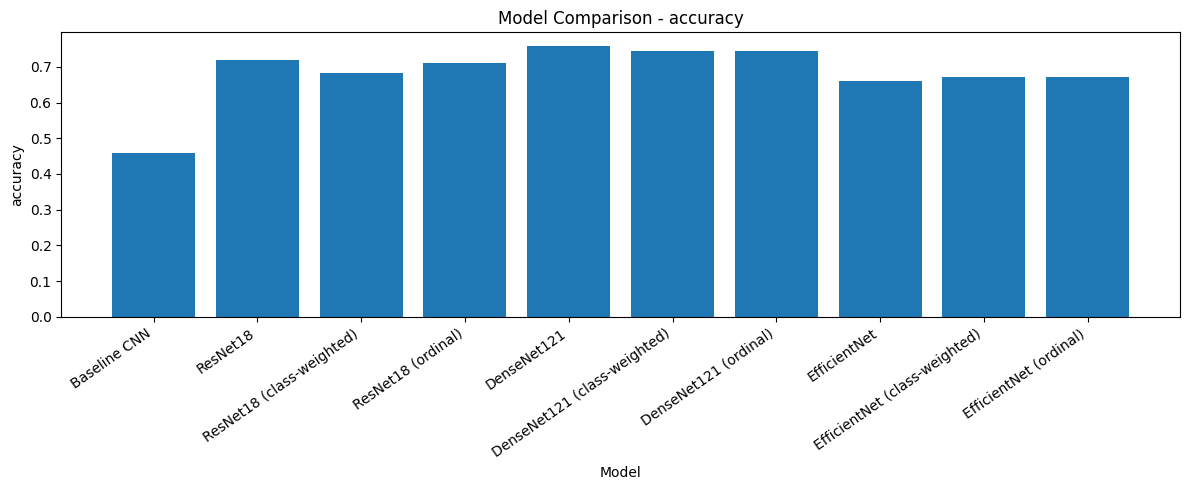

Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\overall_macro_f1.png


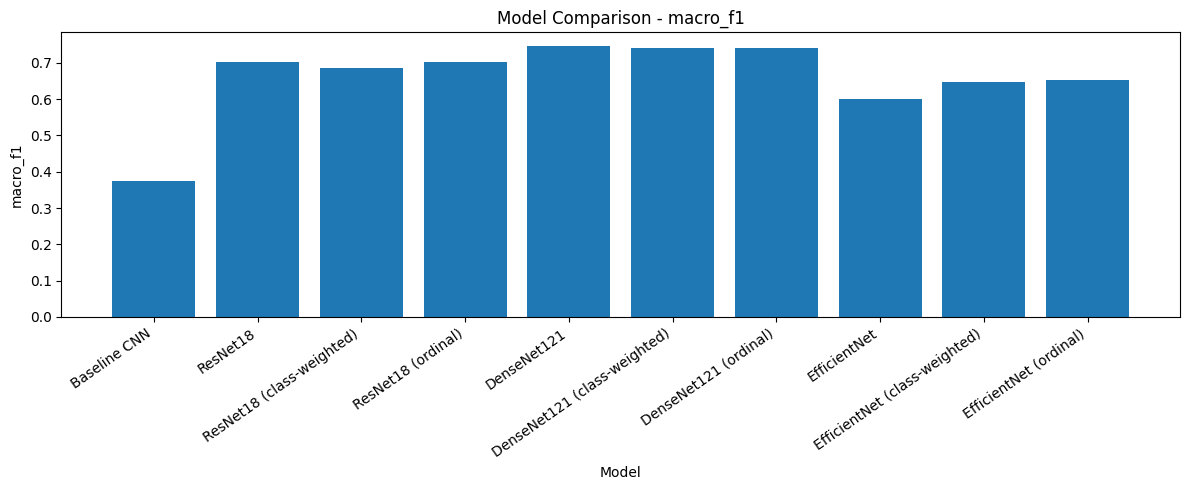

Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\overall_weighted_f1.png


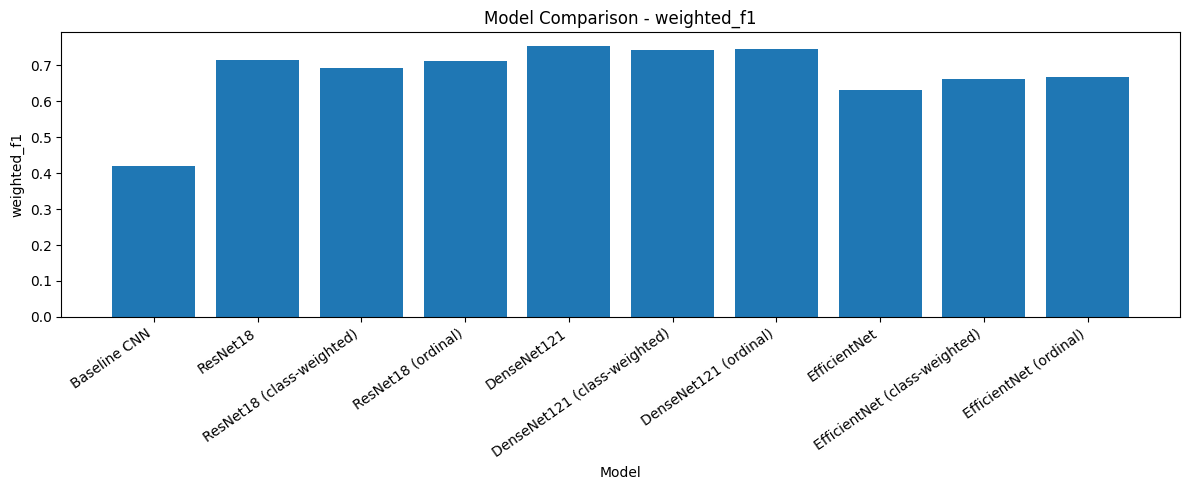

Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\overall_qwk.png


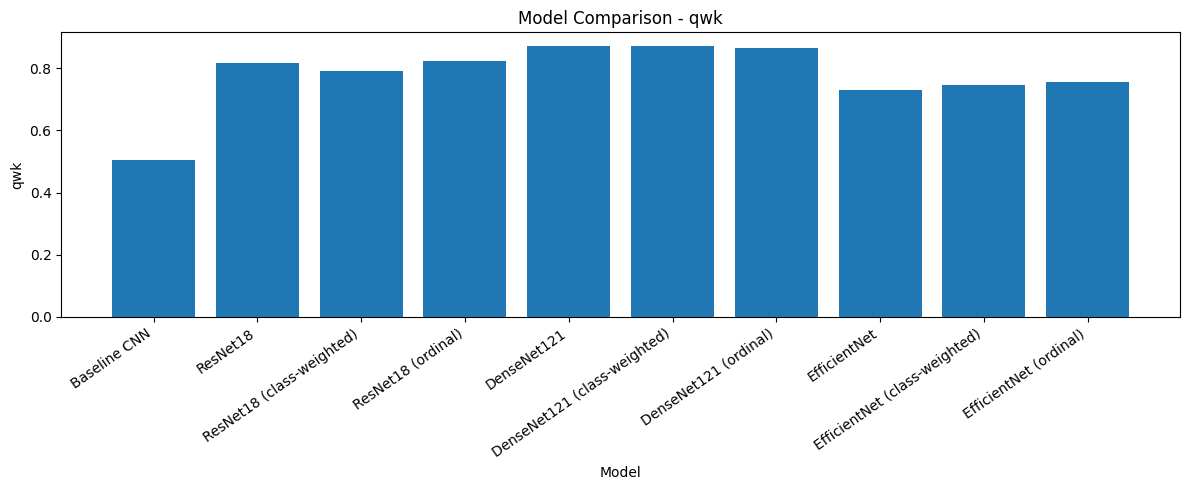

In [14]:
# 7. Plot overall metrics
plot_metrics = ["accuracy", "macro_f1", "weighted_f1", "qwk"]
plot_df = sort_by_model_order(overall_df.copy())

for metric in plot_metrics:
    if metric in plot_df.columns:
        plt.figure(figsize=(12, 5))
        plt.bar(plot_df["model_variant"], plot_df[metric])
        plt.title(f"Model Comparison - {metric}")
        plt.ylabel(metric)
        plt.xlabel("Model")
        plt.xticks(rotation=35, ha="right")
        save_current_figure(f"overall_{metric}.png")
        plt.show()

Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\overall_mae.png


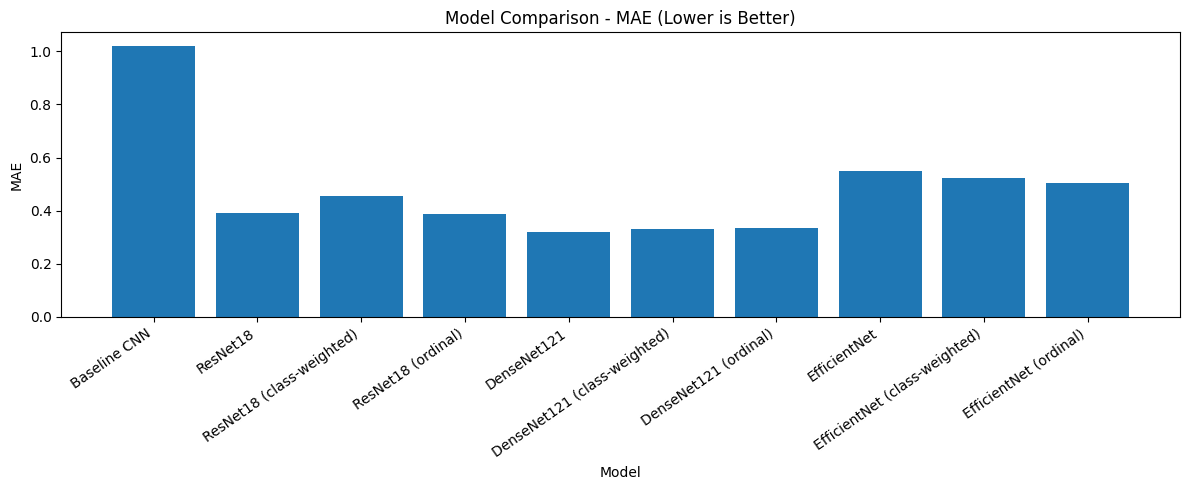

In [10]:
# Plot MAE separately because lower is better
if "mae" in plot_df.columns:
    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["model_variant"], plot_df["mae"])
    plt.title("Model Comparison - MAE (Lower is Better)")
    plt.ylabel("MAE")
    plt.xlabel("Model")
    plt.xticks(rotation=35, ha="right")
    save_current_figure("overall_mae.png")
    plt.show()

## 2 — Per-class F1 comparison

This section checks whether a model performs well across all five OA grades.

This is important because a model can have high accuracy but still perform badly on minority or difficult classes, especially the middle grade such as **Mild**.

In [17]:
# 8. Load all *_per_class_metrics.csv files

per_class_files = sorted(RESULTS_DIR.glob("*_per_class_metrics.csv"))
per_class_rows = []

for file in per_class_files:
    if "comparison" in file.name.lower():
        continue

    raw_model, base_model, variant, display_name = parse_model_variant(file.name)
    df = pd.read_csv(file).copy()

    class_col_candidates = ["class_name", "class", "label_name", "target_name"]
    class_col = next((c for c in class_col_candidates if c in df.columns), None)

    if class_col is None:
        if "label" in df.columns:
            df["class_name"] = df["label"].map(dict(enumerate(CLASS_ORDER))).fillna(df["label"].astype(str))
            class_col = "class_name"
        else:
            df["class_name"] = [CLASS_ORDER[i] if i < len(CLASS_ORDER) else str(i) for i in range(len(df))]
            class_col = "class_name"

    f1_col_candidates = ["f1_score", "f1", "F1", "f1-score"]
    f1_col = next((c for c in f1_col_candidates if c in df.columns), None)

    if f1_col is None:
        print("No F1 column found in", file.name, "columns:", df.columns.tolist())
        continue

    temp = df[[class_col, f1_col]].copy()
    temp.columns = ["class_name", "f1_score"]
    temp["raw_model"] = raw_model
    temp["base_model"] = base_model
    temp["variant"] = variant
    temp["model_variant"] = display_name
    temp["source_file"] = file.name
    per_class_rows.append(temp)

per_class_long = pd.concat(per_class_rows, ignore_index=True) if per_class_rows else pd.DataFrame()
per_class_long["f1_score"] = pd.to_numeric(per_class_long["f1_score"], errors="coerce")
per_class_long.head(20)

,class_name,f1_score,raw_model,base_model,variant,model_variant,source_file
0,Normal,0.572816,baseline,Baseline CNN,standard,Baseline CNN,baseline_per_class_metrics.csv
1,Doubtful,0.418919,baseline,Baseline CNN,standard,Baseline CNN,baseline_per_class_metrics.csv
2,Mild,0.000000,baseline,Baseline CNN,standard,Baseline CNN,baseline_per_class_metrics.csv
3,Moderate,0.375000,baseline,Baseline CNN,standard,Baseline CNN,baseline_per_class_metrics.csv
4,Severe,0.500000,baseline,Baseline CNN,standard,Baseline CNN,baseline_per_class_metrics.csv
5,Normal,0.804124,densenet121,DenseNet121,class-weighted,DenseNet121 (class-weighted),densenet121_classweighted_per_class_metrics.csv
6,Doubtful,0.690909,densenet121,DenseNet121,class-weighted,DenseNet121 (class-weighted),densenet121_classweighted_per_class_metrics.csv
7,Mild,0.571429,densenet121,DenseNet121,class-weighted,DenseNet121 (class-weighted),densenet121_classweighted_per_class_metrics.csv
8,Moderate,0.810811,densenet121,DenseNet121,class-weighted,DenseNet121 (class-weighted),densenet121_classweighted_per_class_metrics.csv
9,Severe,0.820513,densenet121,DenseNet121,class-weighted,DenseNet121 (class-weighted),densenet121_classweighted_per_class_metrics.csv


In [18]:
# 9. Pivot per-class F1 table

if not per_class_long.empty:
    per_class_pivot = per_class_long.pivot_table(
        index="class_name",
        columns="model_variant",
        values="f1_score",
        aggfunc="mean"
    )

    existing_classes = [c for c in CLASS_ORDER if c in per_class_pivot.index]
    other_classes = [c for c in per_class_pivot.index if c not in existing_classes]
    per_class_pivot = per_class_pivot.loc[existing_classes + other_classes]

    existing_models = [m for m in MODEL_ORDER if m in per_class_pivot.columns]
    other_models = [m for m in per_class_pivot.columns if m not in existing_models]
    per_class_pivot = per_class_pivot[existing_models + other_models]

    per_class_pivot_display = (per_class_pivot * 100).round(2)
else:
    per_class_pivot = pd.DataFrame()
    per_class_pivot_display = pd.DataFrame()

per_class_pivot_display

model_variant,Baseline CNN,ResNet18,ResNet18 (class-weighted),ResNet18 (ordinal),DenseNet121,DenseNet121 (class-weighted),DenseNet121 (ordinal),EfficientNet,EfficientNet (class-weighted),EfficientNet (ordinal)
class_name,,,,,,,,,,
Normal,57.28,80.00,75.29,78.26,80.40,80.41,80.42,78.66,79.65,78.34
Doubtful,41.89,67.39,65.48,67.03,72.62,69.09,70.24,61.20,58.68,60.34
Mild,0.00,47.06,45.83,47.37,56.72,57.14,57.50,23.73,45.57,47.50
Moderate,37.50,80.00,81.08,82.67,81.08,81.08,81.08,70.00,73.17,74.36
Severe,50.00,76.06,75.00,76.47,82.50,82.05,80.52,66.67,66.04,66.04


In [19]:
# Save per-class F1 table
per_class_path = TABLES_DIR / "per_class_f1_comparison.csv"
per_class_pivot_display.to_csv(per_class_path)
print("Saved table:", per_class_path)

Saved table: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\tables\model_comparison\per_class_f1_comparison.csv


Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\per_class_f1_comparison.png


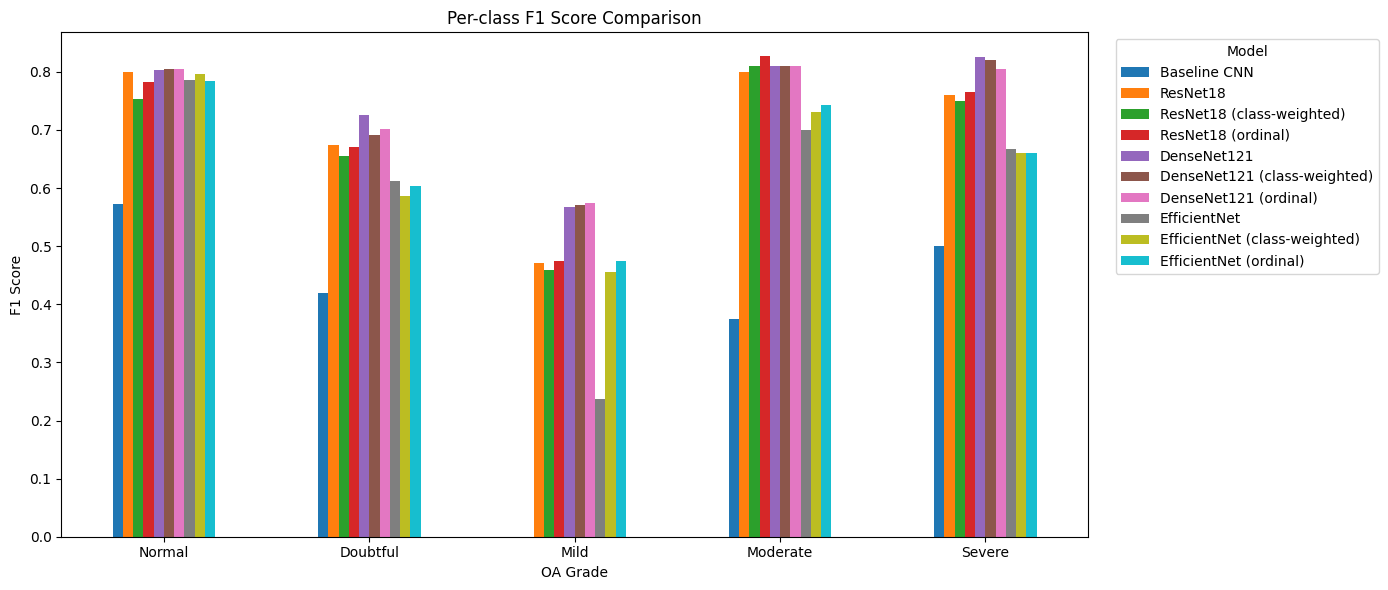

In [26]:
# 10. Plot per-class F1 comparison
if not per_class_pivot.empty:
    per_class_pivot.plot(kind="bar", figsize=(14, 6))
    plt.title("Per-class F1 Score Comparison")
    plt.ylabel("F1 Score")
    plt.xlabel("OA Grade")
    plt.xticks(rotation=0)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_figure("per_class_f1_comparison.png")
    plt.show()

In [27]:
# 11. Identify weak classes for each model

if not per_class_long.empty:
    weakest_class = (
        per_class_long
        .sort_values(["model_variant", "f1_score"], ascending=[True, True])
        .groupby("model_variant")
        .head(1)
        [["model_variant", "class_name", "f1_score"]]
        .reset_index(drop=True)
    )

    weakest_class_display = weakest_class.copy()
    weakest_class_display["f1_score"] = (weakest_class_display["f1_score"] * 100).round(2)
    weakest_class_display = sort_by_model_order(weakest_class_display)
else:
    weakest_class_display = pd.DataFrame()

weakest_class_display

,model_variant,class_name,f1_score
0,Baseline CNN,Mild,0.00
7,ResNet18,Mild,47.06
8,ResNet18 (class-weighted),Mild,45.83
9,ResNet18 (ordinal),Mild,47.37
1,DenseNet121,Mild,56.72
2,DenseNet121 (class-weighted),Mild,57.14
3,DenseNet121 (ordinal),Mild,57.50
4,EfficientNet,Mild,23.73
5,EfficientNet (class-weighted),Mild,45.57
6,EfficientNet (ordinal),Mild,47.50


# 3— Error distance analysis

For OA grading, not all mistakes are equal.

- True Mild → predicted Doubtful: error distance = 1, adjacent error.
- True Normal → predicted Severe: error distance = 4, distant error.

model not only reduce total errors, but also reduce distant errors.

In [28]:
# 12. Error distance comparison

error_distance_file = RESULTS_DIR / "error_distance_comparison.csv"

if error_distance_file.exists():
    error_distance_df = pd.read_csv(error_distance_file)
    print("Loaded existing error_distance_comparison.csv")
else:
    prediction_files = sorted(RESULTS_DIR.glob("*_test_predictions.csv"))
    error_rows = []

    for file in prediction_files:
        raw_model, base_model, variant, display_name = parse_model_variant(file.name)
        pred_df = pd.read_csv(file)

        if "error_distance" in pred_df.columns:
            distances = pd.to_numeric(pred_df["error_distance"], errors="coerce")
        elif {"true_label", "pred_label"}.issubset(pred_df.columns):
            distances = (pd.to_numeric(pred_df["true_label"], errors="coerce") - pd.to_numeric(pred_df["pred_label"], errors="coerce")).abs()
        else:
            print("Cannot infer error distance from", file.name)
            continue

        total = len(distances)
        total_errors = int((distances > 0).sum())
        adjacent_errors = int((distances == 1).sum())
        distant_errors = int((distances >= 2).sum())

        error_rows.append({
            "model_variant": display_name,
            "base_model": base_model,
            "variant": variant,
            "total_samples": total,
            "correct_predictions": int((distances == 0).sum()),
            "total_errors": total_errors,
            "adjacent_errors": adjacent_errors,
            "distant_errors": distant_errors,
            "mae_from_predictions": float(distances.mean()),
            "adjacent_error_rate_among_errors": adjacent_errors / total_errors if total_errors else 0,
            "distant_error_rate_among_errors": distant_errors / total_errors if total_errors else 0,
            "source_file": file.name,
        })

    error_distance_df = pd.DataFrame(error_rows)

if not error_distance_df.empty and "model_variant" in error_distance_df.columns:
    error_distance_df = sort_by_model_order(error_distance_df)

error_distance_display = error_distance_df.copy()
for col in ["adjacent_error_rate_among_errors", "distant_error_rate_among_errors"]:
    if col in error_distance_display.columns:
        error_distance_display[col] = error_distance_display[col].apply(to_percentage_if_needed)
error_distance_display = error_distance_display.round(3)
error_distance_display

Loaded existing error_distance_comparison.csv


,Experiment,Adjacent Error Rate,Distant Error Rate
0,Baseline CNN,0.509,0.491
1,ResNet18,0.747,0.253
2,ResNet18 (class-weighted),0.645,0.355
3,ResNet18 (ordinal),0.753,0.247
4,DenseNet121,0.746,0.254
5,DenseNet121 (class-weighted),0.760,0.240
6,DenseNet121 (ordinal),0.747,0.253
7,EfficientNet,0.607,0.393
8,EfficientNet (class-weighted),0.620,0.380
9,EfficientNet (ordinal),0.667,0.333


In [29]:
# Save error distance table
error_distance_path = TABLES_DIR / "error_distance_comparison.csv"
error_distance_display.to_csv(error_distance_path, index=False)
print("Saved table:", error_distance_path)

Saved table: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\tables\model_comparison\error_distance_comparison.csv


In [31]:
# 13. Plot distant errors
if not error_distance_df.empty and "distant_errors" in error_distance_df.columns:
    plot_error_df = sort_by_model_order(error_distance_df.copy())
    plt.figure(figsize=(12, 5))
    plt.bar(plot_error_df["model_variant"], plot_error_df["distant_errors"])
    plt.title("Distant Error Comparison")
    plt.ylabel("Number of Distant Errors")
    plt.xlabel("Model")
    plt.xticks(rotation=35, ha="right")
    save_current_figure("distant_error_comparison.png")
    plt.show()

# 4 — Confusion matrix analysis

show where the model is making mistakes.

usually happen between neighbouring classes:

- Normal vs Doubtful
- Doubtful vs Mild
- Mild vs Moderate

Large off-diagonal errors are more serious because they mean the model predicts a very different disease severity.

Top models for confusion matrix:


,model_variant,source_file
0,DenseNet121,densenet121_test_metrics.csv
1,DenseNet121 (class-weighted),densenet121_classweighted_test_metrics.csv
2,DenseNet121 (ordinal),densenet121_ordinal_test_metrics.csv


Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\confusion_matrix_densenet121.png


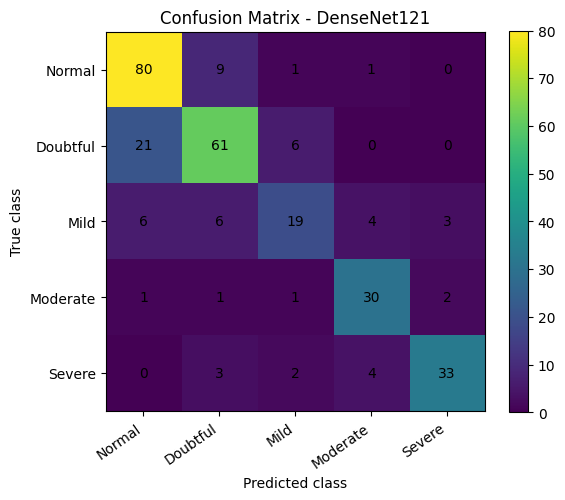

Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\confusion_matrix_densenet121_class_weighted.png


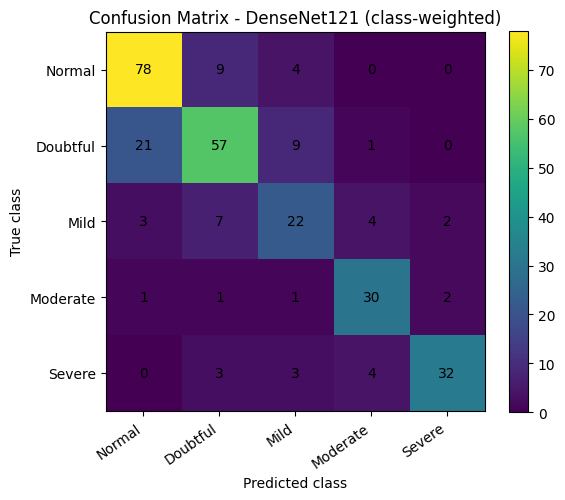

Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\confusion_matrix_densenet121_ordinal.png


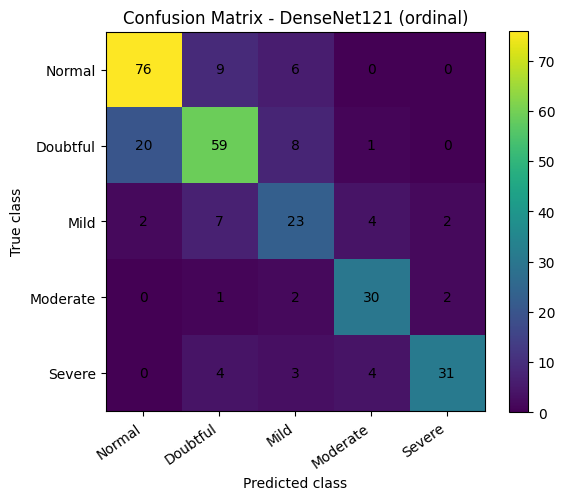

In [34]:
# 14. Load and plot confusion matrices

def load_confusion_matrix(file: Path):
    cm = pd.read_csv(file, index_col=0)
    cm.index = [str(x).replace("true_", "") for x in cm.index]
    cm.columns = [str(x).replace("pred_", "") for x in cm.columns]
    return cm


def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm.values)
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(range(len(cm.columns)), cm.columns, rotation=35, ha="right")
    plt.yticks(range(len(cm.index)), cm.index)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm.values[i, j]), ha="center", va="center")

    plt.colorbar()
    save_current_figure(filename)
    plt.show()

if not ranking_df.empty:
    top_models = ranking_df.head(3)[["model_variant", "source_file"]].copy()
    print("Top models for confusion matrix:")
    display(top_models)

    for _, row in top_models.iterrows():
        source = row["source_file"]
        cm_file_name = source.replace("_test_metrics.csv", "_confusion_matrix.csv")
        cm_file = RESULTS_DIR / cm_file_name

        if cm_file.exists():
            cm = load_confusion_matrix(cm_file)
            safe_name = re.sub(r"[^A-Za-z0-9]+", "_", row["model_variant"]).strip("_").lower()
            plot_confusion_matrix(cm, f"Confusion Matrix - {row['model_variant']}", f"confusion_matrix_{safe_name}.png")
        else:
            print("Missing confusion matrix:", cm_file_name)

# 5 — Training curve comparison

Training curves help explain whether a model converged properly and whether it may be overfitting.

Useful signs:

- Training loss and validation loss both decrease → good convergence.
- Training accuracy increases but validation accuracy stops improving → possible overfitting.
- Validation accuracy is unstable → model may need different learning rate, more regularisation, or more stable augmentation.

In [37]:
# 15. Load training history files

history_files = sorted(RESULTS_DIR.glob("*_training_history.csv"))
history_rows = []

for file in history_files:
    raw_model, base_model, variant, display_name = parse_model_variant(file.name)
    df = pd.read_csv(file).copy()
    df["raw_model"] = raw_model
    df["base_model"] = base_model
    df["variant"] = variant
    df["model_variant"] = display_name
    df["source_file"] = file.name
    history_rows.append(df)

history_df = pd.concat(history_rows, ignore_index=True) if history_rows else pd.DataFrame()
history_df.head()

,epoch,train_loss,train_acc,val_loss,val_acc,raw_model,base_model,variant,model_variant,source_file
0,1,1.510064,0.335938,1.456174,0.363014,baseline,Baseline CNN,standard,Baseline CNN,baseline_training_history.csv
1,2,1.463478,0.368164,1.435935,0.328767,baseline,Baseline CNN,standard,Baseline CNN,baseline_training_history.csv
2,3,1.434830,0.368164,1.470328,0.417808,baseline,Baseline CNN,standard,Baseline CNN,baseline_training_history.csv
3,4,1.408799,0.369141,1.502165,0.424658,baseline,Baseline CNN,standard,Baseline CNN,baseline_training_history.csv
4,5,1.390585,0.378906,1.299966,0.363014,baseline,Baseline CNN,standard,Baseline CNN,baseline_training_history.csv


Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\validation_accuracy_curves_top_models.png


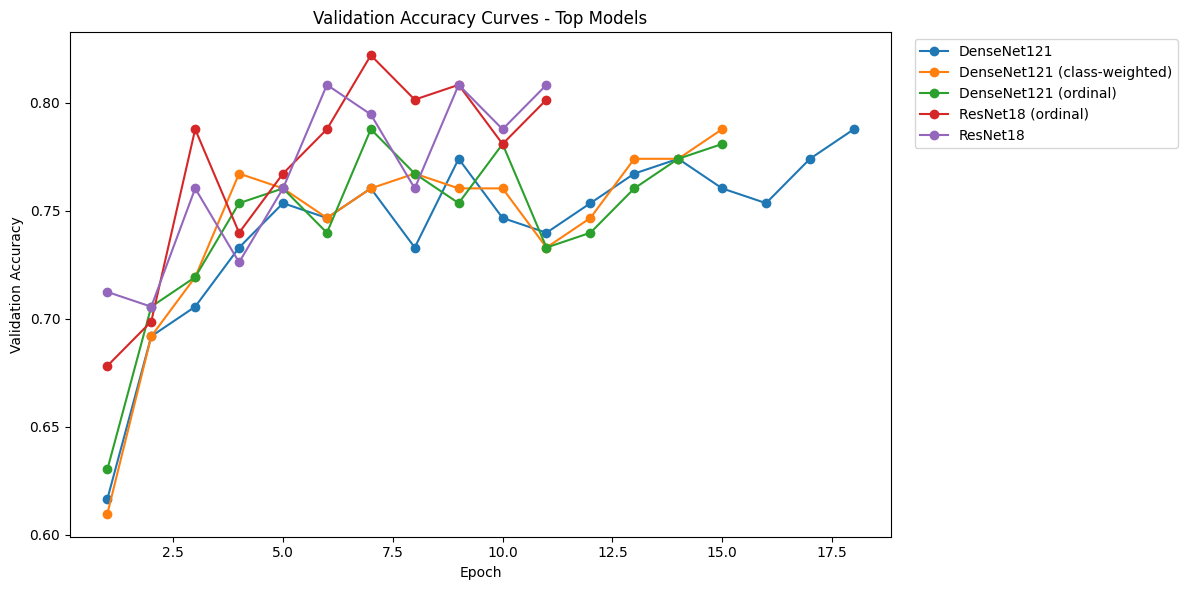

In [38]:
# 16. Plot validation accuracy curves

if not history_df.empty and {"epoch", "val_acc"}.issubset(history_df.columns):
    selected_models = ranking_df.head(5)["model_variant"].tolist() if not ranking_df.empty else history_df["model_variant"].unique().tolist()

    plt.figure(figsize=(12, 6))
    for model_name in selected_models:
        sub = history_df[history_df["model_variant"] == model_name]
        if not sub.empty:
            plt.plot(sub["epoch"], sub["val_acc"], marker="o", label=model_name)

    plt.title("Validation Accuracy Curves - Top Models")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_figure("validation_accuracy_curves_top_models.png")
    plt.show()

Saved figure: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\model_comparison\validation_loss_curves_top_models.png


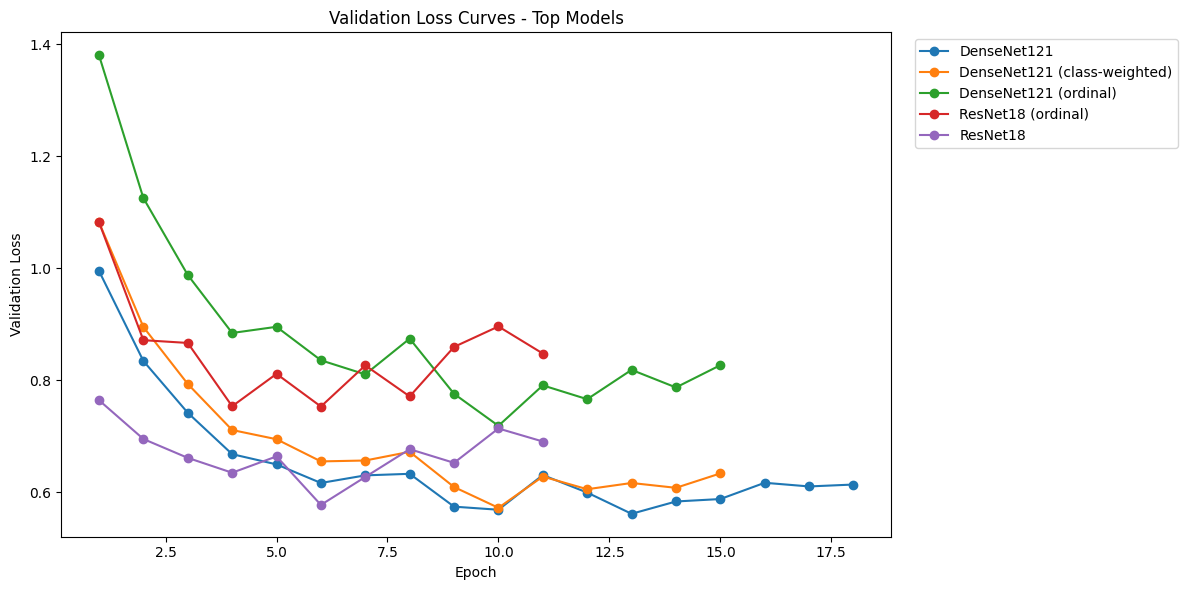

In [22]:
# 17. Plot validation loss curves

if not history_df.empty and {"epoch", "val_loss"}.issubset(history_df.columns):
    selected_models = ranking_df.head(5)["model_variant"].tolist() if not ranking_df.empty else history_df["model_variant"].unique().tolist()

    plt.figure(figsize=(12, 6))
    for model_name in selected_models:
        sub = history_df[history_df["model_variant"] == model_name]
        if not sub.empty:
            plt.plot(sub["epoch"], sub["val_loss"], marker="o", label=model_name)

    plt.title("Validation Loss Curves - Top Models")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_figure("validation_loss_curves_top_models.png")
    plt.show()

# 6 — Deep analysis of the selected best model

In [39]:
# 18. Locate best model prediction file

best_metrics_file = best_model_row["source_file"]
best_predictions_file = RESULTS_DIR / best_metrics_file.replace("_test_metrics.csv", "_test_predictions.csv")
best_gradcam_file = RESULTS_DIR / best_metrics_file.replace("_test_metrics.csv", "_gradcam_predictions.csv")

print("Best model:", best_model_name)
print("Prediction file:", best_predictions_file.name, "exists:", best_predictions_file.exists())
print("Grad-CAM file:", best_gradcam_file.name, "exists:", best_gradcam_file.exists())

if best_predictions_file.exists():
    best_pred_df = pd.read_csv(best_predictions_file)
else:
    best_pred_df = pd.DataFrame()

best_pred_df.head()

Best model: DenseNet121
Prediction file: densenet121_test_predictions.csv exists: True
Grad-CAM file: densenet121_gradcam_predictions.csv exists: True


,sample_index,true_label,true_class,pred_label,pred_class,error_distance,prob_0_Normal,prob_1_Doubtful,prob_2_Mild,prob_3_Moderate,prob_4_Severe
0,0,1,Doubtful,1,Doubtful,0,0.007927,0.981699,0.007983,0.001960,0.000431
1,1,4,Severe,4,Severe,0,0.001003,0.001554,0.007985,0.072987,0.916471
2,2,2,Mild,1,Doubtful,1,0.154861,0.810947,0.030933,0.000528,0.002731
3,3,0,Normal,0,Normal,0,0.992428,0.004699,0.002224,0.000618,0.000032
4,4,0,Normal,1,Doubtful,1,0.468690,0.524514,0.005817,0.000534,0.000445


In [40]:
# 19. Prediction-level error analysis

if not best_pred_df.empty:
    analysis_df = best_pred_df.copy()

    if "error_distance" not in analysis_df.columns and {"true_label", "pred_label"}.issubset(analysis_df.columns):
        analysis_df["error_distance"] = (analysis_df["true_label"] - analysis_df["pred_label"]).abs()

    total = len(analysis_df)
    correct = int((analysis_df["error_distance"] == 0).sum())
    errors = int((analysis_df["error_distance"] > 0).sum())
    adjacent = int((analysis_df["error_distance"] == 1).sum())
    distant = int((analysis_df["error_distance"] >= 2).sum())

    print("Best model:", best_model_name)
    print("Total samples:", total)
    print("Correct predictions:", correct)
    print("Total errors:", errors)
    print("Adjacent errors:", adjacent)
    print("Distant errors:", distant)
    print("MAE:", round(float(analysis_df["error_distance"].mean()), 4))

    error_distribution = analysis_df["error_distance"].value_counts().sort_index().rename_axis("error_distance").reset_index(name="count")
    display(error_distribution)
else:
    print("No prediction file available for the best model.")

Best model: DenseNet121
Total samples: 294
Correct predictions: 223
Total errors: 71
Adjacent errors: 53
Distant errors: 18
MAE: 0.3197


,error_distance,count
0,0,223
1,1,53
2,2,13
3,3,5


In [41]:
# 20. Most common misclassification pairs

if not best_pred_df.empty and {"true_class", "pred_class", "error_distance"}.issubset(best_pred_df.columns):
    mistakes = best_pred_df[best_pred_df["error_distance"] > 0].copy()

    misclassification_pairs = (
        mistakes
        .groupby(["true_class", "pred_class"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    display(misclassification_pairs.head(15))
    misclassification_pairs.to_csv(TABLES_DIR / "best_model_misclassification_pairs.csv", index=False)
    print("Saved table:", TABLES_DIR / "best_model_misclassification_pairs.csv")
else:
    print("Required columns not found for misclassification pair analysis.")

,true_class,pred_class,count
1,Doubtful,Normal,21
10,Normal,Doubtful,9
2,Mild,Doubtful,6
0,Doubtful,Mild,6
4,Mild,Normal,6
3,Mild,Moderate,4
15,Severe,Moderate,4
5,Mild,Severe,3
13,Severe,Doubtful,3
9,Moderate,Severe,2


Saved table: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\tables\model_comparison\best_model_misclassification_pairs.csv


In [42]:
# 21. Confidence analysis for best model

if not best_pred_df.empty:
    prob_cols = [c for c in best_pred_df.columns if c.startswith("prob_")]

    if prob_cols:
        conf_df = best_pred_df.copy()
        conf_df["max_probability"] = conf_df[prob_cols].max(axis=1)
        conf_df["is_correct"] = conf_df["error_distance"] == 0

        print("Average confidence - correct predictions:", round(conf_df.loc[conf_df["is_correct"], "max_probability"].mean(), 4))
        print("Average confidence - wrong predictions:", round(conf_df.loc[~conf_df["is_correct"], "max_probability"].mean(), 4))

        high_conf_wrong = conf_df[~conf_df["is_correct"]].sort_values("max_probability", ascending=False).head(10)
        low_conf_cases = conf_df.sort_values("max_probability", ascending=True).head(10)

        print("High-confidence wrong predictions:")
        display(high_conf_wrong[[c for c in ["sample_index", "true_label", "true_class", "pred_label", "pred_class", "error_distance", "max_probability"] if c in high_conf_wrong.columns]])

        print("Low-confidence cases:")
        display(low_conf_cases[[c for c in ["sample_index", "true_label", "true_class", "pred_label", "pred_class", "error_distance", "max_probability"] if c in low_conf_cases.columns]])

        high_conf_wrong.to_csv(TABLES_DIR / "best_model_high_confidence_wrong_predictions.csv", index=False)
        low_conf_cases.to_csv(TABLES_DIR / "best_model_low_confidence_cases.csv", index=False)
    else:
        print("No probability columns found in prediction file.")

Average confidence - correct predictions: 0.8559
Average confidence - wrong predictions: 0.7053
High-confidence wrong predictions:


,sample_index,true_label,true_class,pred_label,pred_class,error_distance,max_probability
286,286,1,Doubtful,0,Normal,1,0.994377
111,111,2,Mild,3,Moderate,1,0.992397
164,164,2,Mild,3,Moderate,1,0.989302
176,176,2,Mild,3,Moderate,1,0.979673
207,207,2,Mild,0,Normal,2,0.973779
83,83,1,Doubtful,0,Normal,1,0.964620
13,13,1,Doubtful,0,Normal,1,0.957734
200,200,1,Doubtful,0,Normal,1,0.955680
107,107,1,Doubtful,0,Normal,1,0.953912
206,206,1,Doubtful,0,Normal,1,0.953116


Low-confidence cases:


,sample_index,true_label,true_class,pred_label,pred_class,error_distance,max_probability
91,91,1,Doubtful,1,Doubtful,0,0.309616
292,292,4,Severe,4,Severe,0,0.318522
168,168,1,Doubtful,0,Normal,1,0.361158
238,238,0,Normal,2,Mild,2,0.382964
77,77,2,Mild,2,Mild,0,0.396987
30,30,1,Doubtful,1,Doubtful,0,0.420352
156,156,1,Doubtful,1,Doubtful,0,0.422789
203,203,1,Doubtful,1,Doubtful,0,0.430404
15,15,0,Normal,0,Normal,0,0.430856
146,146,2,Mild,2,Mild,0,0.433019


In [43]:
# 22. Read Grad-CAM prediction list if available

if best_gradcam_file.exists():
    gradcam_df = pd.read_csv(best_gradcam_file)
    print("Grad-CAM rows:", len(gradcam_df))
    display(gradcam_df.head(20))
else:
    gradcam_df = pd.DataFrame()
    print("No Grad-CAM prediction file found for the best model.")

Grad-CAM rows: 5


,variant,image_path,true_label,true_class,pred_label,pred_class,confidence,correct,error_distance
0,standard,Z:\cs760-group1\data\raw\Digital Knee X-ray Im...,0,Normal,0,Normal,0.992428,True,0
1,standard,Z:\cs760-group1\data\raw\Digital Knee X-ray Im...,1,Doubtful,1,Doubtful,0.981699,True,0
2,standard,Z:\cs760-group1\data\raw\Digital Knee X-ray Im...,2,Mild,1,Doubtful,0.810947,False,1
3,standard,Z:\cs760-group1\data\raw\Digital Knee X-ray Im...,3,Moderate,3,Moderate,0.852814,True,0
4,standard,Z:\cs760-group1\data\raw\Digital Knee X-ray Im...,4,Severe,4,Severe,0.916471,True,0


# 7 — Automatic report text

The following cell generates short paragraphs that can be copied into the report or presentation.

In [44]:
# =========================
# 23. Generate report-ready summary text
# =========================

if not ranking_df.empty:
    best = ranking_df.iloc[0]

    def fmt_percent(x):
        if pd.isna(x):
            return "N/A"
        return f"{to_percentage_if_needed(x):.2f}%"

    def fmt_number(x):
        if pd.isna(x):
            return "N/A"
        return f"{x:.3f}"

    summary_text = f"""
Based on the current evaluation results, the selected best model is {best['model_variant']}.
This model achieved an accuracy of {fmt_percent(best.get('accuracy', np.nan))}, a macro F1 score of {fmt_percent(best.get('macro_f1', np.nan))}, a weighted F1 score of {fmt_percent(best.get('weighted_f1', np.nan))}, a MAE of {fmt_number(best.get('mae', np.nan))}, and a QWK of {fmt_percent(best.get('qwk', np.nan))}.

The model was selected mainly because macro F1 and QWK are more suitable than accuracy alone for this task. Macro F1 checks whether the model performs well across all OA grades, while QWK is useful because knee osteoarthritis grading is an ordinal classification problem. MAE was also considered because it shows how far the predicted grade is from the true grade.

For further research, this model should be analysed using its confusion matrix, error-distance distribution, high-confidence wrong predictions, and Grad-CAM visualisations. This can help identify whether the model is mainly confused between neighbouring classes or whether it sometimes makes clinically serious distant errors.
""".strip()

    print(summary_text)

    report_text_path = TABLES_DIR / "best_model_report_summary.txt"
    report_text_path.write_text(summary_text, encoding="utf-8")
    print("\nSaved report text:", report_text_path)

Based on the current evaluation results, the selected best model is DenseNet121.
This model achieved an accuracy of 75.85%, a macro F1 score of 74.66%, a weighted F1 score of 75.39%, a MAE of 0.320, and a QWK of 87.20%.

The model was selected mainly because macro F1 and QWK are more suitable than accuracy alone for this task. Macro F1 checks whether the model performs well across all OA grades, while QWK is useful because knee osteoarthritis grading is an ordinal classification problem. MAE was also considered because it shows how far the predicted grade is from the true grade.

For further research, this model should be analysed using its confusion matrix, error-distance distribution, high-confidence wrong predictions, and Grad-CAM visualisations. This can help identify whether the model is mainly confused between neighbouring classes or whether it sometimes makes clinically serious distant errors.

Saved report text: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\tables\mo

# Recommended next steps after selecting the best model

After choosing the best model, the deeper research should focus on:

1. **Error analysis**: identify which OA grades are most often confused.
2. **Distant errors**: check whether the model makes clinically serious mistakes.
3. **Mild class performance**: this is usually difficult because it is visually close to Doubtful and Moderate.
4. **Grad-CAM interpretability**: check whether the model focuses on the knee joint region rather than irrelevant image areas.
5. **Further tuning**: try learning rate adjustment, stronger augmentation, class weighting, ordinal loss, or ensemble methods only after the main comparison is clearly documented.